# RESuM paper reproduction with RESUM-FLEX

This notebook uses RESUM-FLEX to replay the parts of [RESuM: A Rare Event Surrogate Model](https://arxiv.org/abs/2410.03873) supported by the published aggregate data. It does not import or read code from the original repository.

The detector design has five inputs, $\boldsymbol{\theta}=(r,d,n,\phi,L)$: radius, thickness, number of panels, panel angle, and panel length. The final quantity we want to predict is the $^{77(m)}\mathrm{Ge}$ production rate from an expensive high-fidelity simulation.

This is a **practice-truth** example: held-out simulations provide the reference answers. A **theory-truth** example would use a known analytical function instead.

The available files let us refit the multi-fidelity GP and check its predictions. They do not contain enough event-level data to retrain the CNP. Whenever the notebook uses stored CNP outputs instead of recomputing them, it says so.

## 1. Setup and data provenance

The two input CSV files are bundled in `notebooks/data/paper_2410_03873/`. Their source paths and checksums are recorded in the README beside them. No HDF5 file is read, so this notebook does not need `h5py`.

The next two cells load the new RESUM-FLEX implementation, read the CSV files, and assemble the five design columns into one input matrix. They do not fit a model yet. The default GP fit uses 10 optimizer restarts.

In [1]:
from __future__ import annotations

import csv
import os
import sys
import warnings
from pathlib import Path

import GPy
import matplotlib.pyplot as plt
import numpy as np
from emukit.multi_fidelity.convert_lists_to_array import convert_xy_lists_to_arrays
from emukit.multi_fidelity.kernels import LinearMultiFidelityKernel
from emukit.multi_fidelity.models import GPyLinearMultiFidelityModel

project_candidates = [Path.cwd(), *Path.cwd().parents]
PROJECT_ROOT = next(path for path in project_candidates if (path / "core").is_dir())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from core.optimizer import BoxBounds, ExpectedImprovementAcquisition  # noqa: E402
from core.scaling import MinMaxScaler  # noqa: E402
from core.surrogate_mfgp import MultiFidelityGP  # noqa: E402

DATA_ROOT = PROJECT_ROOT / "notebooks" / "data" / "paper_2410_03873"
TRAIN_PATH = DATA_ROOT / "cnp_v1.6_output.csv"
VALIDATION_PATH = DATA_ROOT / "hf_validation_data_v1.2.csv"

missing = [path for path in (TRAIN_PATH, VALIDATION_PATH) if not path.is_file()]
if missing:
    raise FileNotFoundError(
        f"Missing bundled aggregate reproduction data: {missing}"
    )

SEED = 1729
N_RESTARTS = int(os.environ.get("RESUM_GP_RESTARTS", "10"))
np.random.seed(SEED)
warnings.filterwarnings("ignore", category=RuntimeWarning, module="GPy")
print(f"Bundled data root: {DATA_ROOT.relative_to(PROJECT_ROOT)}")
print(f"GP optimizer restarts: {N_RESTARTS}")

Bundled data root: notebooks/data/paper_2410_03873
GP optimizer restarts: 10


In [2]:
THETA_NAMES = ("radius", "thickness", "npanels", "theta", "length")
THETA_LABELS = (
    "Radius [cm]",
    "Thickness [cm]",
    "Number of panels",
    "Panel angle [deg]",
    "Length [cm]",
)
THETA_LOW = np.array([0.0, 0.0, 0.0, 0.0, 0.0])
THETA_HIGH = np.array([265.0, 20.0, 360.0, 90.0, 150.0])
THETA_FIXED = np.array([160.0, 2.0, 40.0, 45.0, 20.0])
theta_scaler = MinMaxScaler.from_bounds(THETA_LOW, THETA_HIGH)


def read_numeric_csv(path: Path, columns: dict[str, str]) -> dict[str, np.ndarray]:
    with path.open(newline="", encoding="utf-8") as stream:
        rows = list(csv.DictReader(stream))
    return {
        output_name: np.asarray([float(row[input_name]) for row in rows])
        for output_name, input_name in columns.items()
    }


train = read_numeric_csv(
    TRAIN_PATH,
    {
        "iteration": "iteration",
        "fidelity": "fidelity",
        "n_samples": "n_samples",
        "radius": "radius",
        "thickness": "thickness",
        "npanels": "npanels",
        "theta": "theta",
        "length": "length",
        "event_count": "y_raw",
        "y_cnp": "y_cnp",
        "y_cnp_error": "y_cnp_err",
        "physical_rate": "y_rGe77[nuc/(kg*yr)]",
    },
)
validation = read_numeric_csv(
    VALIDATION_PATH,
    {
        "fidelity": "Fidelity",
        "radius": "Radius[cm]",
        "thickness": "Thickness[cm]",
        "npanels": "NPanels",
        "theta": "Theta[deg]",
        "length": "Length[cm]",
        "event_count": "y_raw",
        "y_cnp": "y_cnp",
        "y_cnp_error": "y_cnp_err",
        "physical_rate": "y_rGe77[nuc/(kg*yr)]",
    },
)


def theta_matrix(data: dict[str, np.ndarray]) -> np.ndarray:
    return np.column_stack([data[name] for name in THETA_NAMES])


X_train = theta_matrix(train)
X_validation = theta_matrix(validation)

## 2. Artifact audit

Before fitting anything, count the available trials.

| | Paper | Bundled data |
|---|---:|---:|
| Initial LF trials | 304 | 303 |
| Initial HF trials | 4 | 4 |
| Final LF trials | 310 | 309 |
| Final HF trials | 10 | 10 |
| Independent HF validation trials | 100 | 100 |

One LF row is missing from the bundled artifact. We can replay the method, but we cannot claim an exact numerical reproduction.

In [3]:
print("iteration | LF rows | HF rows")
print("----------+---------+--------")
for iteration in range(7):
    included = train["iteration"] <= iteration
    n_lf = int(np.sum(included & (train["fidelity"] == 0)))
    n_hf = int(np.sum(included & (train["fidelity"] == 1)))
    print(f"{iteration:9d} | {n_lf:7d} | {n_hf:7d}")

assert len(validation["physical_rate"]) == 100
assert int(np.sum(train["fidelity"] == 1)) == 10
print(f"Validation rows: {len(validation['physical_rate'])}")
print("Paper final LF total: 310; available aggregate LF total: 309")

iteration | LF rows | HF rows
----------+---------+--------
        0 |     303 |       4
        1 |     304 |       5
        2 |     305 |       6
        3 |     306 |       7
        4 |     307 |       8
        5 |     308 |       9
        6 |     309 |      10
Validation rows: 100
Paper final LF total: 310; available aggregate LF total: 309


## 3. CNP retraining placeholder — unavailable

Each simulated event ends with a binary answer: it either produces the rare background or it does not. A raw trial therefore contains mostly zeros and a small number of ones, which makes its rate noisy.

The CNP replaces each binary event result with a smooth score $\beta_i$ between 0 and 1. The score uses both the detector design $\boldsymbol{\theta}$ and that event's features $\boldsymbol{\varphi}_i$. Averaging the scores gives one smoother number for the whole trial:

$$y_{CNP}(\boldsymbol{\theta})=\frac{1}{N}\sum_{i=1}^{N}\beta_i.$$

Retraining this CNP requires the individual events and the original trained state. Those files are incomplete, so the next code cell is intentionally empty. Later sections load the already-computed `y_cnp` column from CSV.

## 4. Paper Figure 3: aggregate CNP diagnostic replay

This figure uses only the initial low-fidelity trials. For each design parameter it plots:

- the rate calculated from the simulated rare-event count;
- the mean CNP score calculated from the same trial.

The raw rate jumps around because rare counts fluctuate. The CNP score is smoother, so design trends are easier to see. The two quantities have different meanings and units; compare their shapes, not their vertical distance. No GP is fitted in this section.

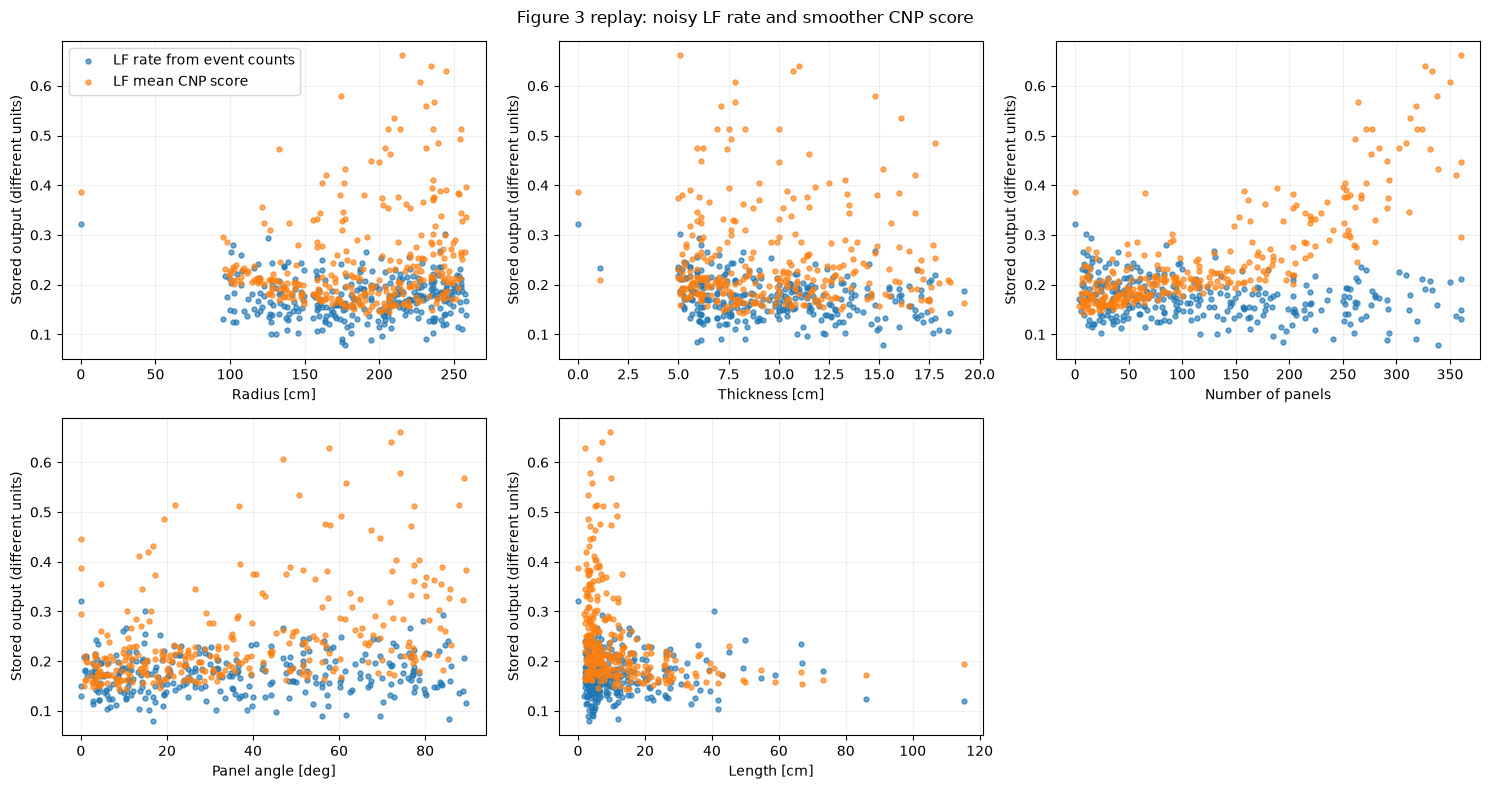

In [4]:
initial_lf = (train["iteration"] == 0) & (train["fidelity"] == 0)
figure, axes = plt.subplots(2, 3, figsize=(15, 8))
for index, (name, label) in enumerate(zip(THETA_NAMES, THETA_LABELS, strict=True)):
    axis = axes.flat[index]
    order = np.argsort(train[name][initial_lf])
    x = train[name][initial_lf][order]
    axis.scatter(
        x, train["physical_rate"][initial_lf][order], s=13, alpha=0.65,
        label="LF rate from event counts",
    )
    axis.scatter(
        x, train["y_cnp"][initial_lf][order], s=13, alpha=0.65,
        label="LF mean CNP score",
    )
    axis.set_xlabel(label)
    axis.set_ylabel("Stored output (different units)")
    axis.grid(alpha=0.2)
axes.flat[0].legend()
axes.flat[-1].axis("off")
figure.suptitle("Figure 3 replay: noisy LF rate and smoother CNP score")
figure.tight_layout()

## 5. Three-fidelity MFGP replay

The model used below is a fitted `MultiFidelityGP` (MFGP). It is not the simulator, and it is not the CNP. The simulator produces event data. The CNP turns one simulation trial into one mean score. The MFGP learns from the stored scores and rates, then predicts them at detector designs that have not been simulated.

The MFGP uses three training outputs:

- **LF mean CNP score:** the average CNP score from 50,000 low-fidelity events. This source is cheap, so the training data contain 309 LF designs.
- **HF mean CNP score:** the average CNP score from 10,000,000 high-fidelity events, using the same trained CNP. The training data contain 10 HF designs.
- **HF measured physical rate:** the rare-event count from a high-fidelity simulation, converted to nuclei/(kg·yr). This is the final prediction target. The training data contain 10 HF designs.

For one detector design, the data flow is:

```text
LF simulator (50,000 events)
└─ trained CNP -> LF mean CNP score

HF simulator (10,000,000 events)
├─ trained CNP       -> HF mean CNP score
└─ rare-event count  -> HF measured physical rate
```

The first two outputs are CNP scores. The third is a physical measurement derived from the HF event count.

A concrete row makes the distinction clearer. At the no-moderator design $\boldsymbol{\theta}=(0,0,0,0,0)$:

- the 50,000-event LF trial gives an LF CNP score of 0.3866;
- the 10,000,000-event HF trial gives an HF CNP score of 0.3836;
- that HF trial contains 626 rare events, which the stored conversion maps to an HF measured rate of 0.238 nuclei/(kg·yr).

The MFGP learns two corrections:

$$\text{HF CNP score}=\rho_0\,\text{LF CNP score}+\delta_1,$$

$$\text{HF measured rate}=\rho_1\,\text{HF CNP score}+\delta_2.$$

Here $\rho$ rescales the previous output and $\delta$ is a GP that learns what the rescaling misses. Before fitting, each design parameter is mapped to $[-1,1]$ so large numerical ranges do not dominate small ones. The replay uses the paper's isotropic RBF kernel and 10 optimizer restarts.

In [5]:
def fit_resum_model(max_iteration: int) -> MultiFidelityGP:
    included = train["iteration"] <= max_iteration
    lf = included & (train["fidelity"] == 0)
    hf = included & (train["fidelity"] == 1)
    X_lf = theta_scaler.transform(X_train[lf])
    X_hf = theta_scaler.transform(X_train[hf])
    model = MultiFidelityGP(3, len(THETA_NAMES), kernel="rbf", ard=False)
    np.random.seed(SEED + max_iteration)
    return model.fit(
        [X_lf, X_hf, X_hf],
        [
            train["y_cnp"][lf, None],
            train["y_cnp"][hf, None],
            train["physical_rate"][hf, None],
        ],
        n_restarts=N_RESTARTS,
    )


resum_models = []
for iteration in range(7):
    print(f"Fitting aggregate replay through iteration {iteration}...")
    resum_models.append(fit_resum_model(iteration))
print("Finished fitting seven sequential surrogate states.")

Fitting aggregate replay through iteration 0...


Fitting aggregate replay through iteration 1...


Fitting aggregate replay through iteration 2...


Fitting aggregate replay through iteration 3...


Fitting aggregate replay through iteration 4...


Fitting aggregate replay through iteration 5...


Fitting aggregate replay through iteration 6...


Finished fitting seven sequential surrogate states.


### Paper Figure 4: sequential one-dimensional projections

Each panel changes one design parameter and holds the other four at $(160,2,40,45,20)$. Every orange line is the model's **HF measured-rate prediction** after one active-learning iteration. Darker lines use more HF trials.

Read this figure as a history: it shows how six new HF trials changed the final prediction. The shaded region is the final one-standard-deviation uncertainty band. The curves are a method replay, not the paper's exact curves, because one LF row and the historical fitted model are missing.

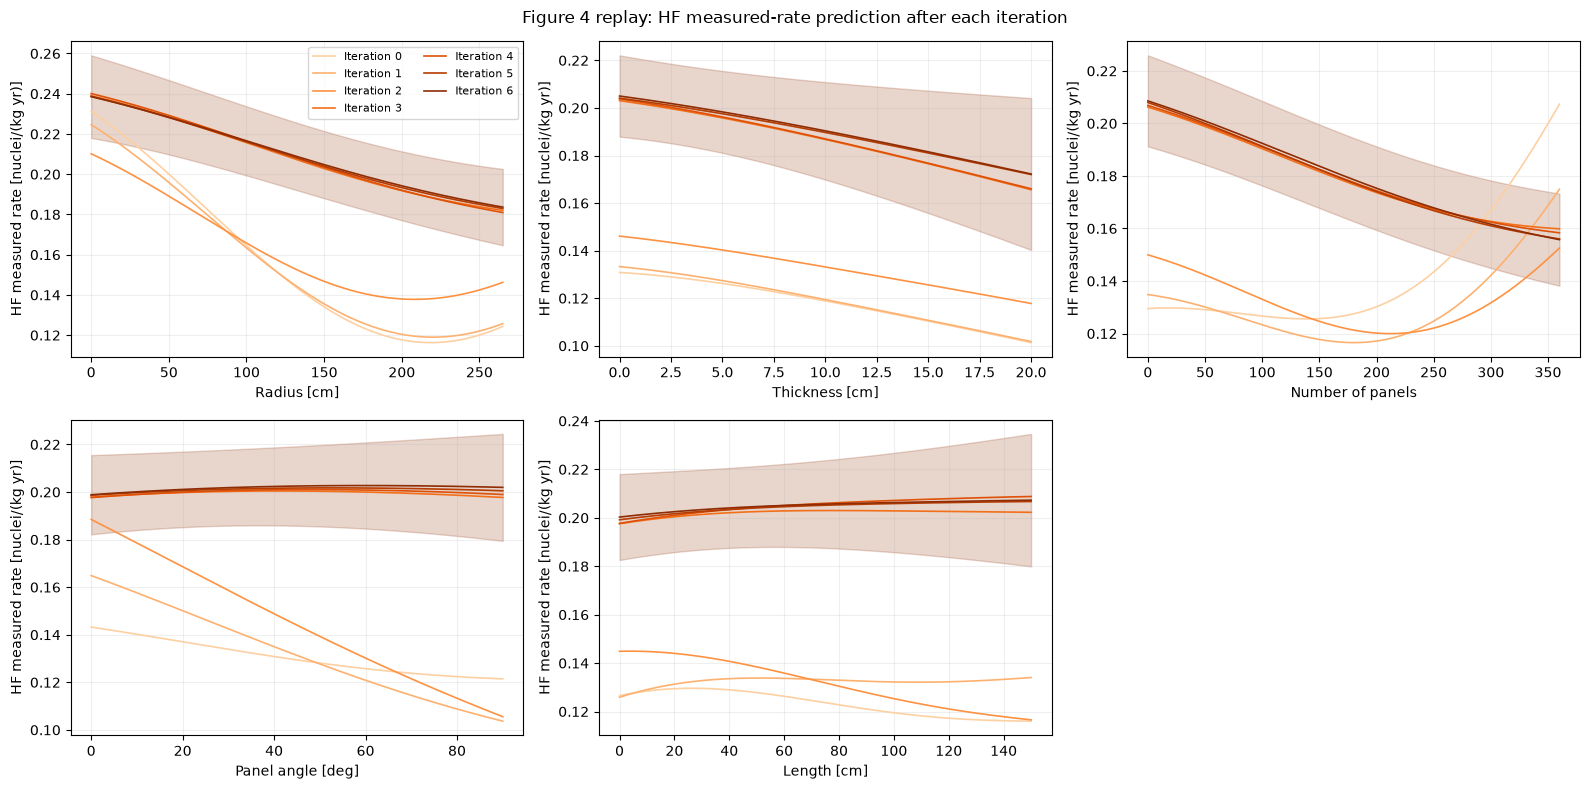

In [6]:
figure, axes = plt.subplots(2, 3, figsize=(16, 8))
iteration_colors = plt.cm.Oranges(np.linspace(0.25, 0.95, 7))
for dimension, label in enumerate(THETA_LABELS):
    axis = axes.flat[dimension]
    grid = np.linspace(THETA_LOW[dimension], THETA_HIGH[dimension], 180)
    query = np.repeat(THETA_FIXED[None, :], len(grid), axis=0)
    query[:, dimension] = grid
    query_scaled = theta_scaler.transform(query)
    for iteration, (model, color) in enumerate(
        zip(resum_models, iteration_colors, strict=True)
    ):
        mean, variance = model.predict(query_scaled, fidelity=2)
        axis.plot(grid, mean, color=color, linewidth=1.2, label=f"Iteration {iteration}")
        if iteration == 6:
            sigma = np.sqrt(variance)
            axis.fill_between(grid, mean - sigma, mean + sigma, color=color, alpha=0.2)
    axis.set_xlabel(label)
    axis.set_ylabel("HF measured rate [nuclei/(kg yr)]")
    axis.grid(alpha=0.2)
axes.flat[-1].axis("off")
axes.flat[0].legend(ncol=2, fontsize=8)
figure.suptitle("Figure 4 replay: HF measured-rate prediction after each iteration")
figure.tight_layout()

### Predictions from the fitted MultiFidelityGP

This plot uses the MFGP fitted after iteration 6. At every x-axis value, the fitted MFGP returns a predicted mean and uncertainty for each training output:

- light cyan, left y-axis: predicted LF mean CNP score;
- dark cyan, left y-axis: predicted HF mean CNP score;
- orange, right y-axis: predicted HF measured physical rate.

The solid lines are MFGP predictions, not new simulation results. The shaded regions show one standard deviation of prediction uncertainty. If the two cyan curves differ, the MFGP has learned an LF-to-HF correction. If the orange curve differs from dark cyan, it has learned a CNP-score-to-physical-rate correction.

CNP score and physical rate use separate y-axes because they are different quantities. Compare how their shapes change with each design parameter. Use the validation section below to judge accuracy.

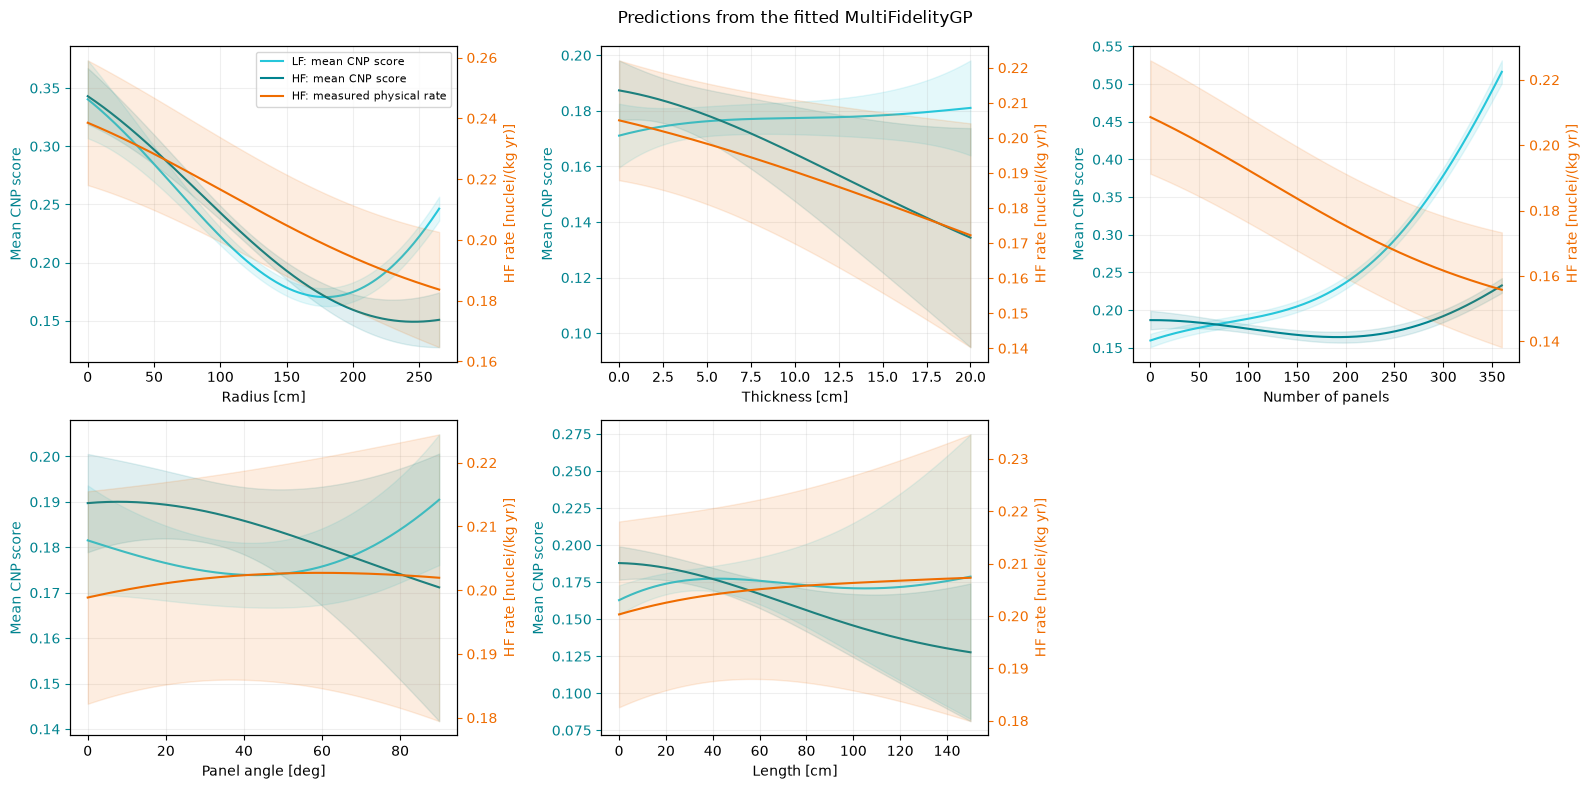

In [7]:
cnp_labels = ("LF: mean CNP score", "HF: mean CNP score")
cnp_colors = ("#26c6da", "#00838f")
rate_label = "HF: measured physical rate"
rate_color = "#ef6c00"
final_model = resum_models[-1]
figure, axes = plt.subplots(2, 3, figsize=(16, 8))
for dimension, label in enumerate(THETA_LABELS):
    cnp_axis = axes.flat[dimension]
    rate_axis = cnp_axis.twinx()
    grid = np.linspace(THETA_LOW[dimension], THETA_HIGH[dimension], 180)
    query = np.repeat(THETA_FIXED[None, :], len(grid), axis=0)
    query[:, dimension] = grid
    query_scaled = theta_scaler.transform(query)
    legend_handles = []
    for fidelity, (fidelity_label, color) in enumerate(
        zip(cnp_labels, cnp_colors, strict=True)
    ):
        mean, variance = final_model.predict(query_scaled, fidelity=fidelity)
        sigma = np.sqrt(variance)
        line, = cnp_axis.plot(grid, mean, color=color, label=fidelity_label)
        cnp_axis.fill_between(
            grid, mean - sigma, mean + sigma, color=color, alpha=0.12
        )
        legend_handles.append(line)
    rate_mean, rate_variance = final_model.predict(query_scaled, fidelity=2)
    rate_sigma = np.sqrt(rate_variance)
    rate_line, = rate_axis.plot(
        grid, rate_mean, color=rate_color, label=rate_label
    )
    rate_axis.fill_between(
        grid,
        rate_mean - rate_sigma,
        rate_mean + rate_sigma,
        color=rate_color,
        alpha=0.12,
    )
    legend_handles.append(rate_line)
    cnp_axis.set_xlabel(label)
    cnp_axis.set_ylabel("Mean CNP score", color=cnp_colors[1])
    rate_axis.set_ylabel("HF rate [nuclei/(kg yr)]", color=rate_color)
    cnp_axis.tick_params(axis="y", colors=cnp_colors[1])
    rate_axis.tick_params(axis="y", colors=rate_color)
    cnp_axis.grid(alpha=0.2)
    if dimension == 0:
        cnp_axis.legend(handles=legend_handles, fontsize=8)
axes.flat[-1].axis("off")
figure.suptitle("Predictions from the fitted MultiFidelityGP")
figure.tight_layout()

### Paper Figure 4: choosing the next HF simulation with EI

Expected Improvement (EI) answers one practical question: **if we can afford one more HF simulation, which candidate is most likely to beat the best rate seen so far?**

For a candidate design, its possible improvement is

$$I(\boldsymbol{\theta})=\max(R_{best}-R(\boldsymbol{\theta}),0).$$

The rate $R(\boldsymbol{\theta})$ is unknown before running the simulation, so the GP averages this improvement over its predictive distribution: $EI=\mathbb{E}[I]$. A low predicted rate raises EI. Large uncertainty can also raise EI because the candidate might turn out better than expected.

In the plot, only radius changes. Thickness stays at 2 cm, panel count at 40, angle at 45 degrees, and length at 20 cm. Early iterations peak near 220 cm, so that part of this one-dimensional slice looked promising. Later curves are nearly zero, so the model no longer expects this slice to beat its current best result. This does **not** mean the full five-dimensional search is finished. The plot also omits the full geometry constraints, so it explains the acquisition mechanism rather than reproducing the exact selected designs.

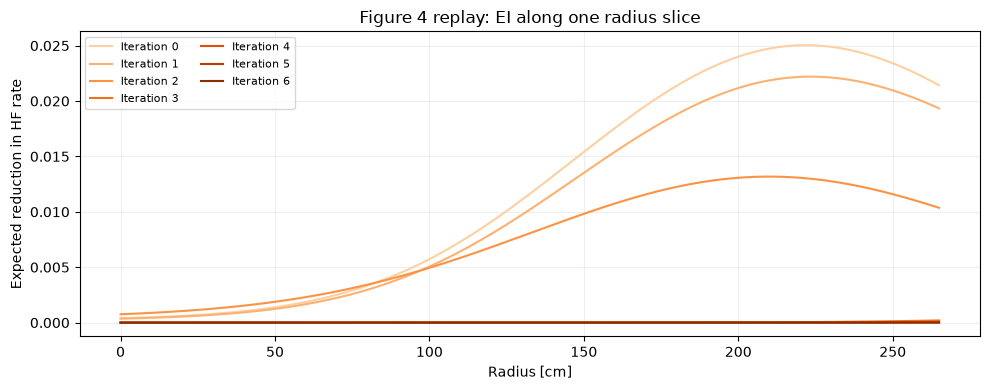

In [8]:
radius_grid = np.linspace(THETA_LOW[0], THETA_HIGH[0], 300)
radius_query = np.repeat(THETA_FIXED[None, :], len(radius_grid), axis=0)
radius_query[:, 0] = radius_grid
radius_query_scaled = theta_scaler.transform(radius_query)
scaled_bounds = BoxBounds(low=-np.ones(5), high=np.ones(5))

figure, axis = plt.subplots(figsize=(10, 4))
for iteration, (model, color) in enumerate(
    zip(resum_models, iteration_colors, strict=True)
):
    hf = (train["iteration"] <= iteration) & (train["fidelity"] == 1)
    acquisition = ExpectedImprovementAcquisition(
        model,
        scaled_bounds,
        incumbent=float(np.min(train["physical_rate"][hf])),
        target="min",
        fidelity=2,
    )
    score = acquisition.score(radius_query_scaled)
    axis.plot(radius_grid, score, color=color, label=f"Iteration {iteration}")
axis.set_xlabel("Radius [cm]")
axis.set_ylabel("Expected reduction in HF rate")
axis.set_title("Figure 4 replay: EI along one radius slice")
axis.legend(ncol=2, fontsize=8)
axis.grid(alpha=0.2)
figure.tight_layout()

## 6. Paper Figure 5: independent HF validation replay

Now test the final HF measured-rate prediction against 100 independent HF simulations. Black points are the simulation results, the orange line is the predicted mean, and the colored regions are the one-, two-, and three-standard-deviation bands.

Coverage is the percentage of black points inside each band:

$$C_q=100\times\frac{\#\{|R_i-\mu_i|\le q\sigma_i\}}{100},\qquad q=1,2,3.$$

The paper reports 69%, 95%, and 100%. This replay obtains 67%, 89%, and 96%. The points are sorted by predicted mean only to make the plot readable; sorting does not change coverage.

Coverage (%) | 1 sigma | 2 sigma | 3 sigma
-------------+---------+---------+--------
Paper        |    69.0 |    95.0 |   100.0
Replay       |    67.0 |    89.0 |    96.0


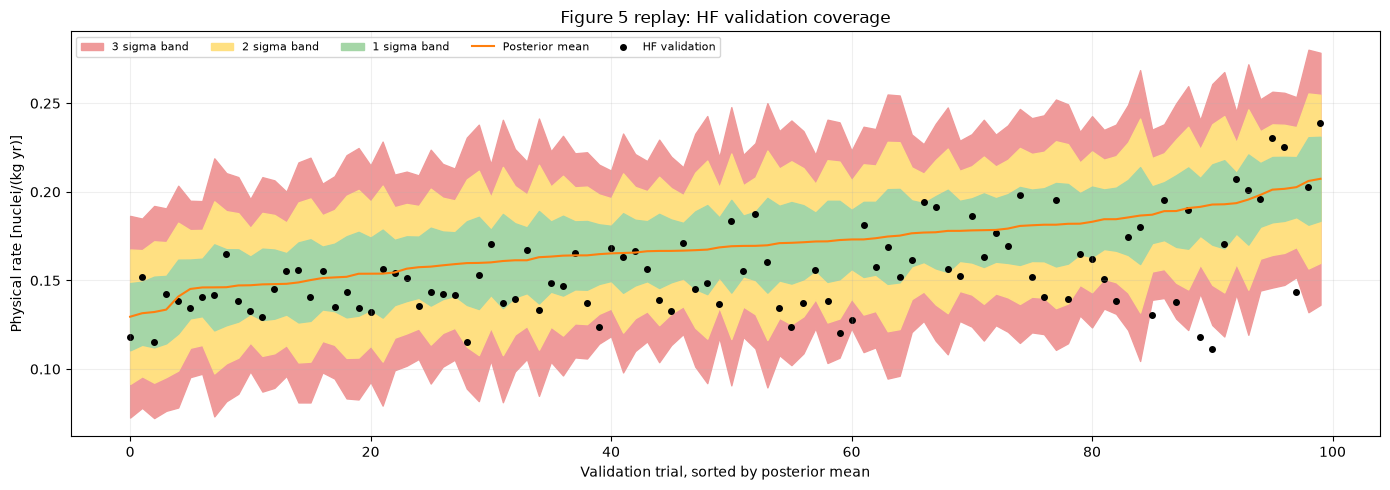

In [9]:
def coverage_percentages(
    model: MultiFidelityGP,
    X: np.ndarray,
    target: np.ndarray,
) -> tuple[np.ndarray, np.ndarray, dict[int, float]]:
    mean, variance = model.predict(theta_scaler.transform(X))
    sigma = np.sqrt(variance)
    coverage = {
        level: 100.0 * float(np.mean(np.abs(target - mean) <= level * sigma))
        for level in (1, 2, 3)
    }
    return mean, sigma, coverage


validation_target = validation["physical_rate"]
resum_mean, resum_sigma, resum_coverage = coverage_percentages(
    resum_models[-1], X_validation, validation_target
)
print("Coverage (%) | 1 sigma | 2 sigma | 3 sigma")
print("-------------+---------+---------+--------")
print("Paper        |    69.0 |    95.0 |   100.0")
print(
    "Replay       | "
    + " | ".join(f"{resum_coverage[level]:7.1f}" for level in (1, 2, 3))
)

order = np.argsort(resum_mean)
trial = np.arange(len(order))
figure, axis = plt.subplots(figsize=(14, 5))
colors = {3: "#ef9a9a", 2: "#ffe082", 1: "#a5d6a7"}
for level in (3, 2, 1):
    axis.fill_between(
        trial,
        resum_mean[order] - level * resum_sigma[order],
        resum_mean[order] + level * resum_sigma[order],
        color=colors[level],
        label=f"{level} sigma band",
    )
axis.plot(trial, resum_mean[order], color="tab:orange", label="Posterior mean")
axis.scatter(trial, validation_target[order], s=16, color="black", label="HF validation")
axis.set_xlabel("Validation trial, sorted by posterior mean")
axis.set_ylabel("Physical rate [nuclei/(kg yr)]")
axis.set_title("Figure 5 replay: HF validation coverage")
axis.legend(ncol=5, fontsize=8)
axis.grid(alpha=0.2)
figure.tight_layout()

## 7. Paper Figure 7: two no-CNP refits

Both cases remove the CNP-score layers and connect LF measured rate directly to HF measured rate. They use the same bundled rate data, but they are different Gaussian-process models. Validation trials stay in their original CSV order, exactly as in the paper figure; the x-axis is the trial number, not a sorted model output.

A GP has two different uncertainties. The latent-function variance $\operatorname{Var}[f_*(\boldsymbol{\theta})\mid\mathcal{D}]$ measures uncertainty about the underlying rate function. The future-observation variance also includes measurement noise:

$$\operatorname{Var}[R_*\mid\mathcal{D}]=\operatorname{Var}[f_*\mid\mathcal{D}]+\sigma_n^2.$$

The original visualizer calls GPy's default `predict()`, which includes likelihood noise. Its HF noise is fixed to zero, so at HF this is effectively the latent-function variance apart from numerical jitter. The current RESUM-FLEX model learns a nonzero HF noise and its public `predict()` follows the same GPy default, so its future-observation band is wider. This notebook keeps those confirmed call semantics even when the resulting coverage differs from the paper.

### 7.1 Historical-code approximation

The first cell reconstructs the mathematical choices and update schedule visible in the original repository history. It uses the unscaled design vector $\boldsymbol{\theta}=(r,d,n,\phi,L)$ and models

$$f_0(\boldsymbol{\theta})\approx R_{LF}(\boldsymbol{\theta}),$$

$$f_1(\boldsymbol{\theta})=\rho f_0(\boldsymbol{\theta})+\delta(r)\approx R_{HF}(\boldsymbol{\theta}).$$

The base GP sees all five design parameters, but the discrepancy $\delta$ sees radius only. The original code first optimizes on the iteration-0 data, then appends the six later LF/HF pairs without re-optimizing the hyperparameters. It computes the LF rate standard deviation and passes that number to GPy's noise-variance parameter; the HF noise is fixed near zero. This cell preserves those confirmed choices.

This is not the exact paper model. One historical notebook revision appends LF `y_cnp` after the initial raw-rate fit, contradicting the paper's statement that Figure 7 excludes CNP outputs. This cell follows the paper's raw-only definition instead of copying that apparent wiring error. The final Figure 7 fitting state and fitted parameters are absent, so the reported 12%, 24%, and 47% coverage cannot be recomputed exactly.

Coverage (%)                | 1 sigma | 2 sigma | 3 sigma
----------------------------+---------+---------+--------
Paper reported              |    12.0 |    24.0 |    47.0
Historical-code approximation |    91.0 |    99.0 |    99.0
Fixed LF noise parameter: variance=0.040204, implied sigma=0.200510


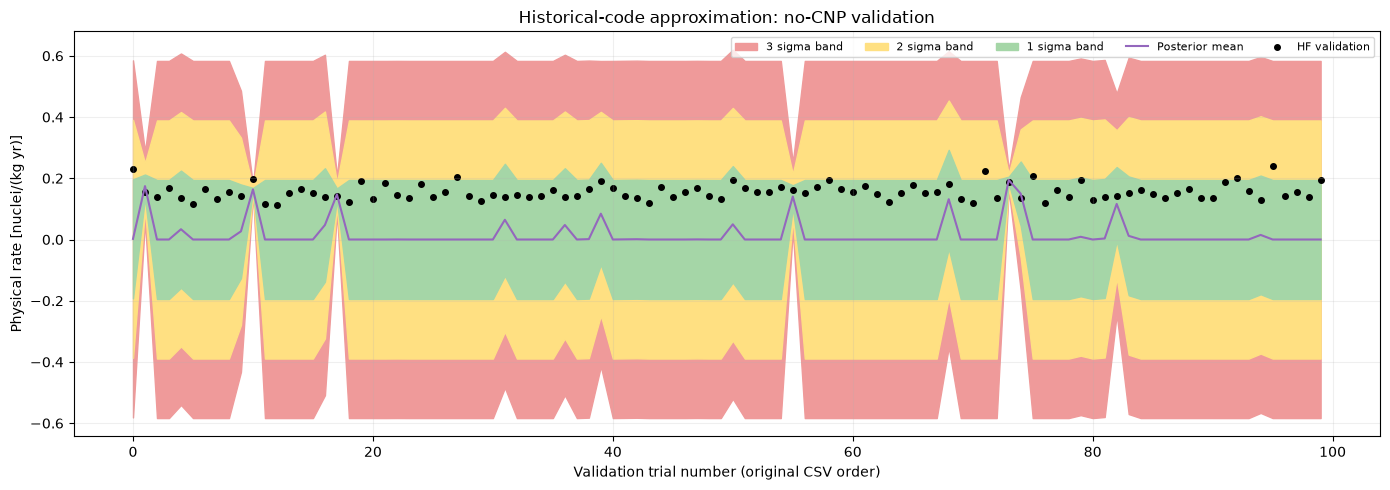

In [10]:
lf = train["fidelity"] == 0
hf = train["fidelity"] == 1
initial_lf = lf & (train["iteration"] == 0)
initial_hf = hf & (train["iteration"] == 0)
historical_X, historical_Y = convert_xy_lists_to_arrays(
    [X_train[initial_lf], X_train[initial_hf]],
    [
        train["physical_rate"][initial_lf, None],
        train["physical_rate"][initial_hf, None],
    ],
)
historical_kernels = [
    GPy.kern.RBF(len(THETA_NAMES), ARD=False, name="lf_rate"),
    GPy.kern.RBF(1, active_dims=[0], ARD=False, name="radius_discrepancy"),
]
historical_no_cnp_model = GPyLinearMultiFidelityModel(
    historical_X,
    historical_Y,
    LinearMultiFidelityKernel(historical_kernels),
    n_fidelities=2,
)
historical_lf_noise_parameter = float(
    np.std(train["physical_rate"][initial_lf])
)
historical_no_cnp_model.mixed_noise.Gaussian_noise.fix(
    historical_lf_noise_parameter
)
historical_no_cnp_model.mixed_noise.Gaussian_noise_1.fix(1e-8)
np.random.seed(123)
historical_no_cnp_model.optimize_restarts(
    num_restarts=N_RESTARTS, verbose=False
)
for iteration in range(1, 7):
    included = train["iteration"] <= iteration
    updated_lf = included & lf
    updated_hf = included & hf
    historical_X, historical_Y = convert_xy_lists_to_arrays(
        [X_train[updated_lf], X_train[updated_hf]],
        [
            train["physical_rate"][updated_lf, None],
            train["physical_rate"][updated_hf, None],
        ],
    )
    historical_no_cnp_model.update_model(False)
    historical_no_cnp_model.Y_metadata = {
        "output_index": historical_X[:, -1].astype(int)
    }
    historical_no_cnp_model.set_XY(historical_X, historical_Y)
    historical_no_cnp_model.update_model(True)


def summarize_prediction(
    mean: np.ndarray,
    variance: np.ndarray,
    target: np.ndarray,
) -> tuple[np.ndarray, dict[int, float]]:
    sigma = np.sqrt(np.clip(variance, 0.0, None))
    coverage = {
        level: 100.0 * float(np.mean(np.abs(target - mean) <= level * sigma))
        for level in (1, 2, 3)
    }
    return sigma, coverage


def plot_validation_replay(
    mean: np.ndarray,
    sigma: np.ndarray,
    title: str,
    line_color: str,
) -> None:
    trial = np.arange(len(mean))
    figure, axis = plt.subplots(figsize=(14, 5))
    for level in (3, 2, 1):
        axis.fill_between(
            trial,
            mean - level * sigma,
            mean + level * sigma,
            color=colors[level],
            label=f"{level} sigma band",
        )
    axis.plot(trial, mean, color=line_color, label="Posterior mean")
    axis.scatter(
        trial, validation_target, s=16, color="black", label="HF validation"
    )
    axis.set_xlabel("Validation trial number (original CSV order)")
    axis.set_ylabel("Physical rate [nuclei/(kg yr)]")
    axis.set_title(title)
    axis.legend(ncol=5, fontsize=8)
    axis.grid(alpha=0.2)
    figure.tight_layout()


historical_fidelity = np.ones((len(X_validation), 1), dtype=int)
historical_mean_2d, historical_variance_2d = historical_no_cnp_model.predict(
    np.column_stack([X_validation, historical_fidelity]),
    Y_metadata={"output_index": historical_fidelity},
    include_likelihood=True,
)
historical_mean = historical_mean_2d[:, 0]
historical_sigma, historical_coverage = summarize_prediction(
    historical_mean, historical_variance_2d[:, 0], validation_target
)
print("Coverage (%)                | 1 sigma | 2 sigma | 3 sigma")
print("----------------------------+---------+---------+--------")
print("Paper reported              |    12.0 |    24.0 |    47.0")
print(
    "Historical-code approximation | "
    + " | ".join(f"{historical_coverage[level]:7.1f}" for level in (1, 2, 3))
)
print(
    "Fixed LF noise parameter: "
    f"variance={historical_lf_noise_parameter:.6f}, "
    f"implied sigma={np.sqrt(historical_lf_noise_parameter):.6f}"
)
plot_validation_replay(
    historical_mean,
    historical_sigma,
    "Historical-code approximation: no-CNP validation",
    "tab:purple",
)

### 7.2 Current RESUM-FLEX refit

The second cell uses the current **MultiFidelityGP**. First, every parameter is scaled to $[-1,1]$:

$$\widetilde{\theta}_j=2\frac{\theta_j-\theta_j^{min}}{\theta_j^{max}-\theta_j^{min}}-1.$$

It then models

$$f_0(\widetilde{\boldsymbol{\theta}})\approx R_{LF}(\widetilde{\boldsymbol{\theta}}),$$

$$f_1(\widetilde{\boldsymbol{\theta}})=\rho f_0(\widetilde{\boldsymbol{\theta}})+\delta(\widetilde{\boldsymbol{\theta}})\approx R_{HF}(\widetilde{\boldsymbol{\theta}}).$$

Here the discrepancy $\delta$ sees all five scaled parameters. The observation model is $R_s=f_s+\epsilon_s$, with $\epsilon_s\sim\mathcal{N}(0,\sigma_{n,s}^2)$. GPy learns each $\sigma_{n,s}^2$ together with the kernel parameters instead of fixing it before fitting. The public `MultiFidelityGP.predict()` follows GPy's default and returns the future-observation variance $\sigma_{f,*}^2+\sigma_{n,HF}^2$, so that is the band plotted below. The latent-function coverage is printed only as a diagnostic; it is not selected to match the paper's reported numbers.

Coverage (%)                  | 1 sigma | 2 sigma | 3 sigma
------------------------------+---------+---------+--------
Paper reported                |    12.0 |    24.0 |    47.0
Future-observation band       |    61.0 |    95.0 |    99.0
Latent-function diagnostic    |    20.0 |    41.0 |    57.0
Learned noise variances: LF=0.001255, HF=0.000301
Mean one-sigma width: future observation=0.018658, latent=0.006581


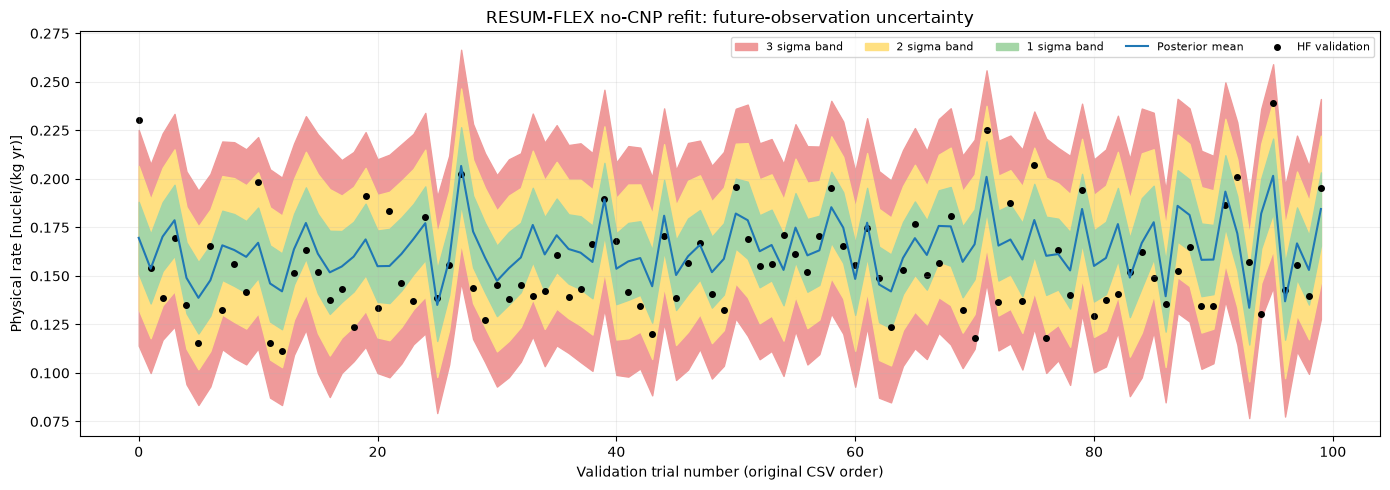

In [11]:
def fit_current_no_cnp_model() -> MultiFidelityGP:
    X_lf = theta_scaler.transform(X_train[lf])
    X_hf = theta_scaler.transform(X_train[hf])
    model = MultiFidelityGP(2, len(THETA_NAMES), kernel="rbf", ard=False)
    np.random.seed(SEED + 100)
    return model.fit(
        [X_lf, X_hf],
        [
            train["physical_rate"][lf, None],
            train["physical_rate"][hf, None],
        ],
        n_restarts=N_RESTARTS,
    )


current_no_cnp_model = fit_current_no_cnp_model()
current_mean, current_sigma, current_coverage = coverage_percentages(
    current_no_cnp_model, X_validation, validation_target
)
current_fidelity = np.ones((len(X_validation), 1), dtype=int)
current_query = np.column_stack(
    [theta_scaler.transform(X_validation), current_fidelity]
)
current_mean_2d, current_latent_variance_2d = current_no_cnp_model.model.predict(
    current_query,
    Y_metadata={"output_index": current_fidelity},
    include_likelihood=False,
)
current_latent_mean = current_mean_2d[:, 0]
current_latent_sigma, current_latent_coverage = summarize_prediction(
    current_latent_mean,
    current_latent_variance_2d[:, 0],
    validation_target,
)
learned_noise = [
    float(
        np.asarray(
            getattr(
                current_no_cnp_model.model.mixed_noise,
                "Gaussian_noise" if index == 0 else f"Gaussian_noise_{index}",
            ).variance
        ).reshape(-1)[0]
    )
    for index in range(2)
]
print("Coverage (%)                  | 1 sigma | 2 sigma | 3 sigma")
print("------------------------------+---------+---------+--------")
print("Paper reported                |    12.0 |    24.0 |    47.0")
print(
    "Future-observation band       | "
    + " | ".join(f"{current_coverage[level]:7.1f}" for level in (1, 2, 3))
)
print(
    "Latent-function diagnostic    | "
    + " | ".join(
        f"{current_latent_coverage[level]:7.1f}"
        for level in (1, 2, 3)
    )
)
print(
    "Learned noise variances: "
    f"LF={learned_noise[0]:.6f}, HF={learned_noise[1]:.6f}"
)
print(
    "Mean one-sigma width: "
    f"future observation={np.mean(current_sigma):.6f}, "
    f"latent={np.mean(current_latent_sigma):.6f}"
)
plot_validation_replay(
    current_mean,
    current_sigma,
    "RESUM-FLEX no-CNP refit: future-observation uncertainty",
    "tab:blue",
)

### 7.3 Interpretation boundary

These cells compare two executable fitting choices; they do not recover the paper's missing fitted state. The historical-code reconstruction produces very wide bands because a rate standard deviation is used as a GP variance and the hyperparameters are optimized only on the initial data. The current refit learns its noise and hyperparameters from all available rows; its public prediction includes the learned HF observation noise. These are logic differences, not tuning choices made to approach the paper's coverage.

The original repository's plotting function preserves validation-file order. One historical no-CNP revision also appends LF `y_cnp` values to the nominally raw-only model, which conflicts with both its initial data and the paper text; this notebook does not silently copy that wiring error. A change in input coordinates, discrepancy dimensions, noise treatment, optimization schedule, dependency versions, or optimizer solution changes the result. The reported coverage remains an unreproduced observation until the exact Figure 7 code or fitted state is available.

## 8. Reproduction boundary

| Paper result | Status in this notebook | Reason |
|---|---|---|
| Initial and sequential design samples | Aggregate replay | Stored CSV rows are available, but one initial LF row is missing |
| CNP training and event-level diagnostics | Unavailable | Complete LF/HF event corpus and current checkpoint are absent |
| Figure 3 CNP comparison | Partial aggregate replay | Stored trial averages exist; event-level CNP outputs do not |
| Figure 4 sequential predictions | Aggregate replay | Stored CNP outputs and active-learning rows are available |
| Figure 4 acquisition | One-dimensional method replay | Exact fitted state and full historical constraints are unavailable |
| 100-trial HF coverage | Aggregate replay | Validation targets are complete; exact historical model state is absent |
| No-CNP ablation | Two executable refits | Historical-code and current-framework choices are compared; the exact paper state is absent |
| Table 1 optimum | Unavailable exactly | Exact fitted surrogate and complete constraints are absent |
| End-to-end CPU cost claim | Not recomputed | Simulation jobs and accounting records are not included |

An exact reproduction still needs the complete LF/HF event data, the missing LF row, the original CNP state or full training recipe, exact package versions, GP noise settings, optimizer seeds, and geometry constraints.